# [LAB 09] 2. 회귀분석의 가정점검
## #01. 준비작업
### 1. 라이브러리 참조

In [16]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from pandas import DataFrame

import seaborn as sb
import numpy as np

# 선형회귀를 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, kstest
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

### 2. 데이터 가져오기

In [17]:
origin = load_data('cars')
origin.head()

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)

field    description
-------  -------------
speed    속도
dist     제동거리



,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


### 3. 단순선형회귀

In [18]:
fit = my_ols.fit_model(origin, y='dist')
fit

### 4. 잔차의 이해

> **회귀선과 실제값의 수직 거리 → 선형회귀 가정 검정의 대상**

| 구분 | 정리 |
|---|---|
| **정의** | $e_i = y_i - \hat{y}_i$<br>잔차는 **실제 관측값**에서 **회귀식이 예측한 값**을 뺀 값이다. |
| **cars 데이터** | $\widehat{dist} = 3.932 \times speed - 17.579$<br>속도(`speed`)로 제동거리(`dist`)를 예측한 뒤, 실제 제동거리와 예측 제동거리의 차이를 잔차로 본다. |
| **방향** | 실제값이 회귀선보다 위에 있으면 $e_i > 0$, 아래에 있으면 $e_i < 0$이다. |
| **검정 대상** | 잔차의 패턴을 보고 선형성, 정규성, 등분산성, 독립성 가정을 점검한다. |

#### 핵심 성질

| 성질 | 의미 |
|---|---|
| $\sum e_i = 0$ | 잔차의 평균은 0이다. 판단의 기준선은 항상 0이다. |
| 잔차 = 데이터 − 모형 | 모형이 설명하지 못하고 놓친 신호가 잔차에 남는다. |
| 잔차 $e$ ≠ 오차 $\epsilon$ | 오차는 관측할 수 없고, 잔차는 오차를 표본에서 추정한 값이다. |

#### 해석 포인트

- 잔차가 0을 중심으로 특별한 패턴 없이 흩어져 있으면 회귀모형이 비교적 적절하다고 볼 수 있다.
- 잔차가 곡선 형태로 휘거나, 예측값이 커질수록 퍼짐이 커지거나, 특정 순서대로 이어지면 회귀분석 가정을 다시 점검해야 한다.

## #02. 가정 검정을 위한 준비
### 1. 예측값을 직접 구하기

In [19]:
y_pred = my_ols.predict(fit, origin[['speed']])
y_pred.head()

,pred
0,-1.849
1,-1.849
2,9.948
3,9.948
4,13.880


### 2. 회귀분석 결과 객체에 내장되어 있는 예측값
- predict() 메서드에 전달되는 파라미터가 분석에 사용된 데이터와 동일하다면 내장되어있는 값을 사용해도 동일하다.
    - predict() 메서드는 수집된 샘플 이외에 새로운 입력값에 댛간 예측치를 얻고자 할 경우 사용

In [20]:
y_pred_values = fit.fittedvalues
y_pred_values.head()

0   -1.849
1   -1.849
2    9.948
3    9.948
4   13.880
dtype: float64

### 3. 잔차 직접 구하기
- 종속변수 - 예측값

In [21]:
residual = origin['dist'] - y_pred['pred']
residual.head()

0    3.849
1   11.849
2   -5.948
3   12.052
4    2.120
dtype: float64

### 4. 회귀분석 결과에 내장되어 있는 잔차 가져오기

In [22]:
residual_values = fit.resid
residual_values.head()

0    3.849
1   11.849
2   -5.948
3   12.052
4    2.120
dtype: float64

### 5. 분석 데이터에 결합

In [23]:
ols_df = origin.copy()
ols_df['y_pred'] = fit.fittedvalues
ols_df['resid'] = fit.resid
ols_df.head()

,speed,dist,y_pred,resid
0,4,2,-1.849,3.849
1,4,10,-1.849,11.849
2,7,4,9.948,-5.948
3,7,22,9.948,12.052
4,8,16,13.880,2.120


### 선형성(Linearity) 검정

선형성은 **독립변수(X)와 종속변수(Y)의 관계를 직선으로 충분히 설명할 수 있는지** 확인하는 가정이다.주로 **잔차(Residual) vs 예측값(Fitted Values)** 산점도에서 LOWESS 추세선을 보고 판단한다.

- x축: 예측값(Fitted Values)
- y축: 잔차(Residuals)
- 기준선: y = 0

---

## 1. 선형성 만족

<p align="center">
  <img src="./images/linearity_ok.svg" width="520">
</p>

LOWESS 추세선이 0선을 따라 거의 평평하고, 잔차가 0을 중심으로 무작위로 흩어져 있으면 선형성 가정을 만족한다고 볼 수 있다.

**판단 기준**

- LOWESS 추세선이 거의 평평함
- 잔차가 0을 중심으로 무작위 분포
- 일정한 방향으로 휘어지는 곡선 패턴 없음

→ **선형성 만족**

---

## 2. 선형성 위반: U자형 패턴

<p align="center">
  <img src="./images/linearity_u_shape.svg" width="520">
</p>

LOWESS 추세선이 U자형 또는 역 U자형으로 휘면 직선 관계만으로는 데이터를 충분히 설명하지 못한다는 신호다.

**판단 기준**

- LOWESS가 U자형 또는 역 U자형으로 휘어짐
- 잔차가 무작위가 아니라 체계적인 곡선 패턴을 보임
- 직선 모형에 비선형 관계가 남아 있음

→ **선형성 위반 가능성**

---

## 3. 선형성 위반: S자형 패턴

<p align="center">
  <img src="./images/linearity_s_shape.svg" width="520">
</p>

S자형처럼 한 방향으로 체계적으로 휘는 패턴도 선형성 위반으로 볼 수 있다.
단순 직선 모형이 실제 관계를 충분히 따라가지 못하는 경우다.

**대응 방법**

- 다항항 추가: `x²`, `x³`
- 변수 변환: `log`, `sqrt`
- 비선형 모델 검토

---

## 4. 부채꼴 패턴은 선형성 문제가 아님

<p align="center">
  <img src="./images/heteroscedasticity_fan.svg" width="520">
</p>

LOWESS 추세선이 평평하더라도 잔차의 퍼짐이 점점 커지는 형태가 나타날 수 있다.
이 경우는 선형성 문제가 아니라 **등분산성 문제**로 보는 것이 적절하다.

**구분 기준**

- 곡선 패턴 → 선형성 문제
- 부채꼴 패턴 → 등분산성 문제

---

## 읽는 순서

1. **모양 먼저 확인**LOWESS가 평평한지, 한 방향으로 체계적으로 휘어지는지 확인한다.
2. **진폭은 보조적으로 확인**LOWESS가 약간 흔들리는 것은 데이터 수가 적거나 일부 이상치 영향일 수 있다.중요한 것은 움직임의 크기보다 **일정한 방향의 패턴이 있는지**이다.
3. **애매하면 통계 검정 수행**
   시각적으로 판단하기 어려운 경우 Ramsey RESET 검정 등을 추가로 사용할 수 있다.

---

## 핵심 요약

| 구분             | 그래프 특징                          | 판단             |
| ---------------- | ------------------------------------ | ---------------- |
| 선형성 만족      | LOWESS가 0선 주변에서 평평함         | 선형성 만족      |
| U자형 / 역 U자형 | LOWESS가 곡선 형태로 휨              | 선형성 위반 가능 |
| S자형            | LOWESS가 한 방향으로 체계적으로 휨   | 선형성 위반 가능 |
| 부채꼴           | LOWESS는 평평하지만 잔차 퍼짐이 커짐 | 등분산성 문제    |

## #03. 잔차의 선형성 검정
### 1. 시각화를 통한 검정
- 예측값에 따른 잔차에 대한 산점도+추세선 그래프를 그린다.
- 모든 예측값에서 가운데 점선에 맞추어 잔차가 비슷하게 있어야 한다.
- 빨간 실선은 잔차의 추세를 의미
    - 빨간 실선이 점선에서 크게 벗어난다면 잔차가 크게 달라진다는 의미이므로 선형성이 없다는 것이다.

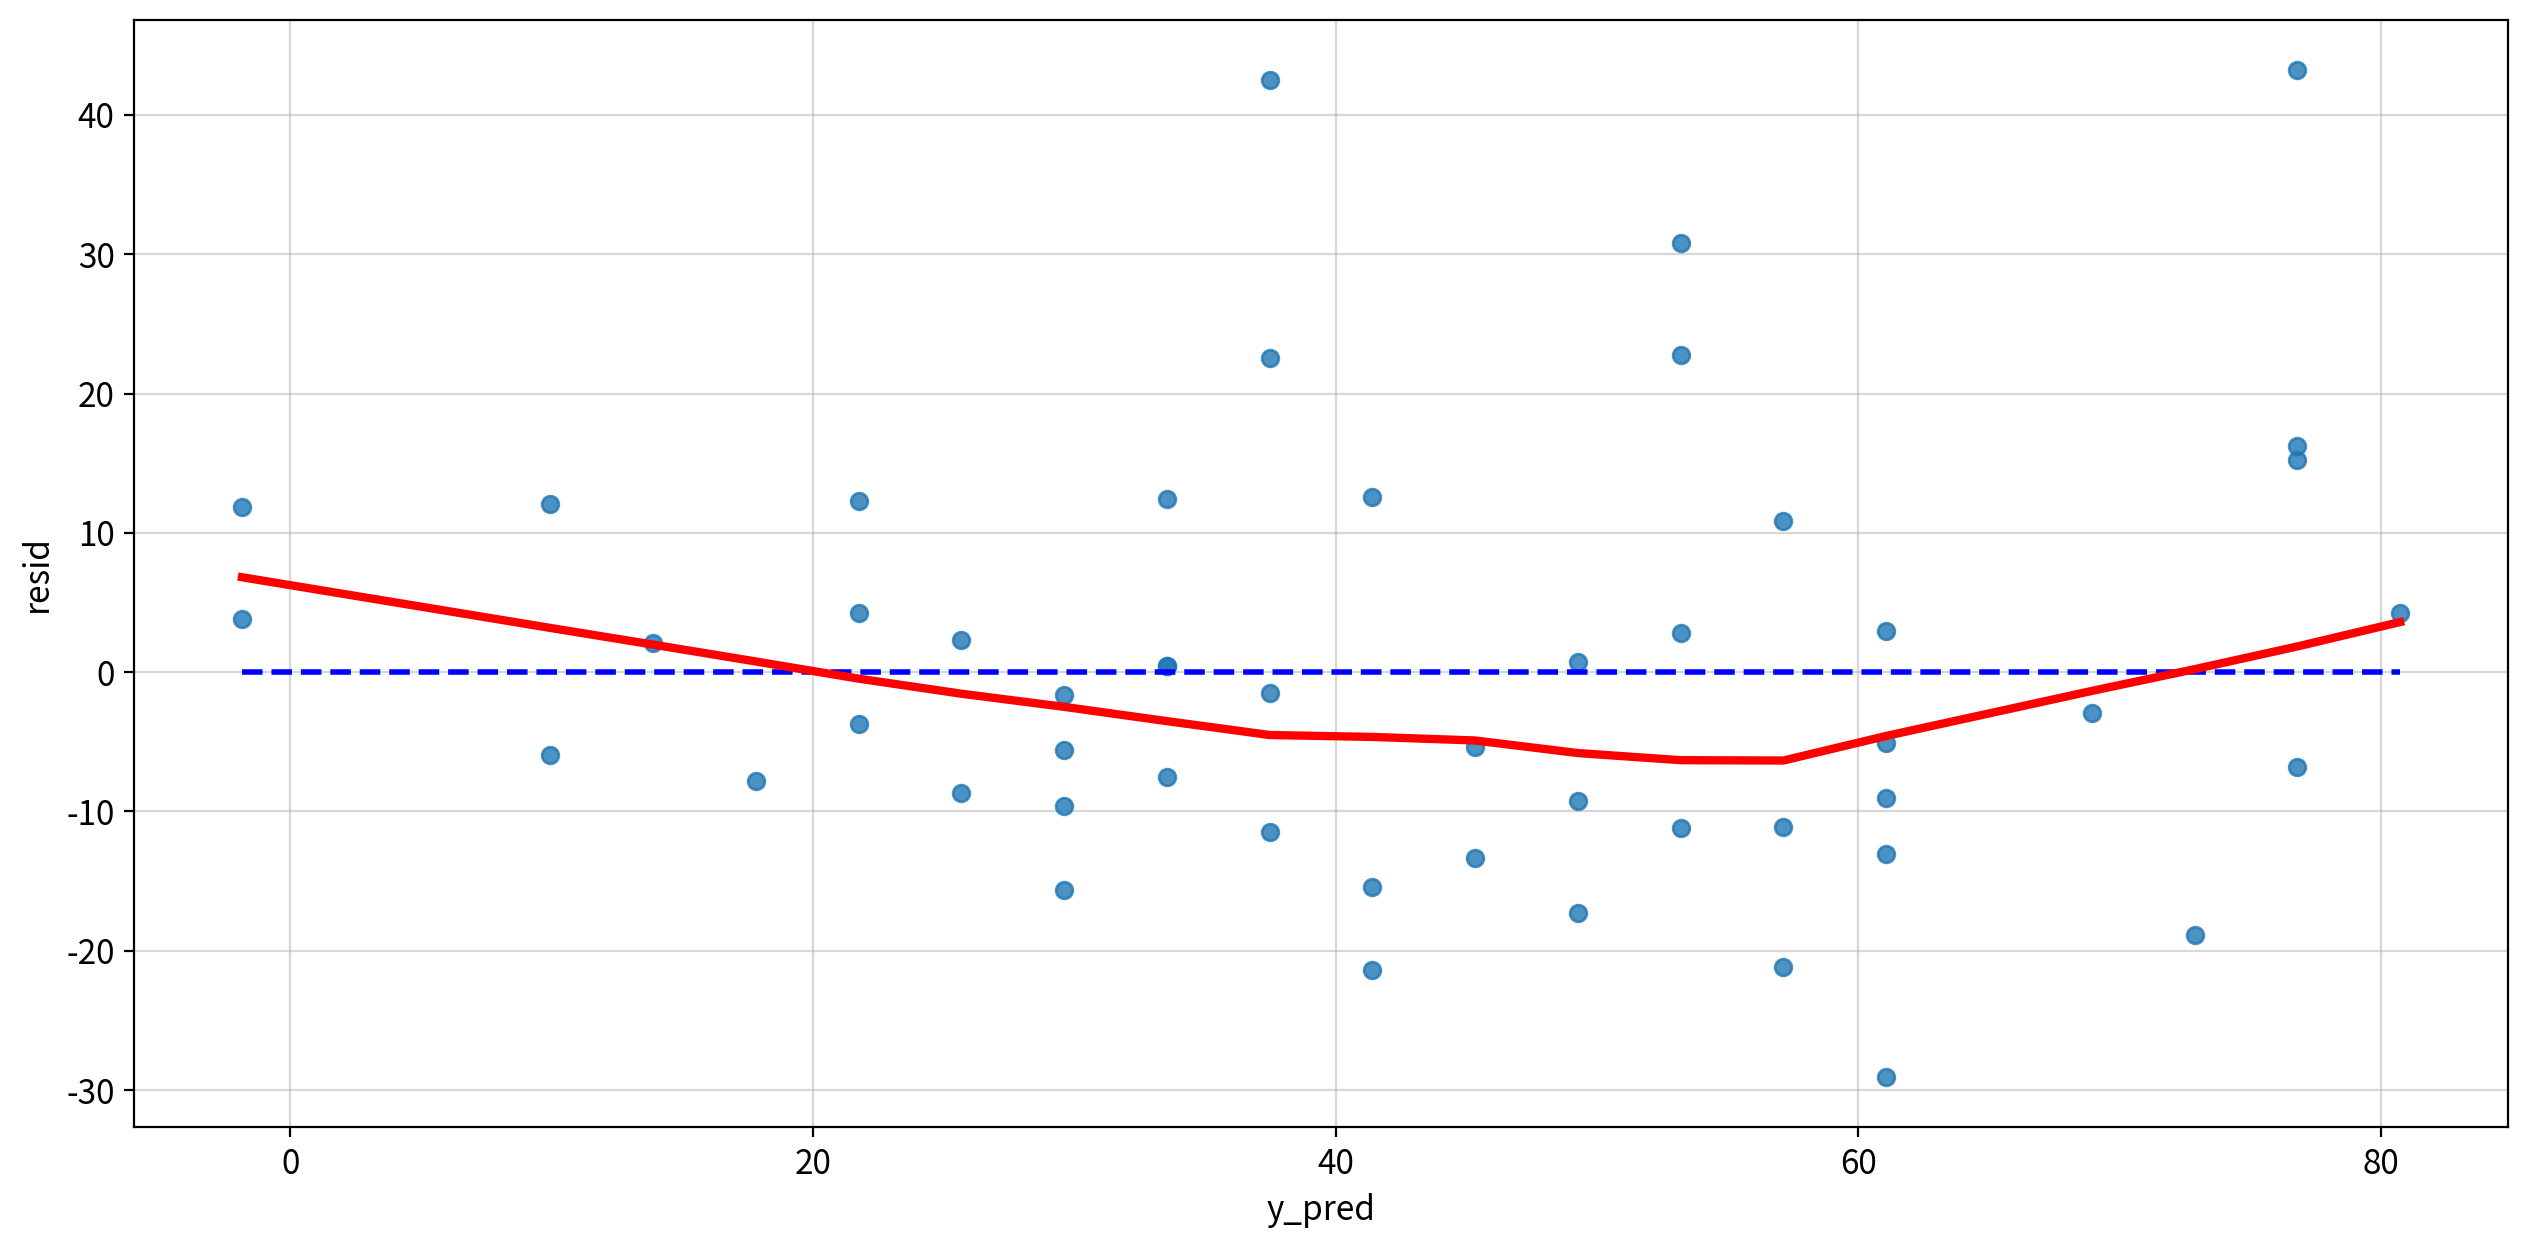

In [24]:
xmin = ols_df['y_pred'].min()   # 예측값(y_pred)의 최솟값 -> 기준선을 그릴 x축 시작점
xmax = ols_df['y_pred'].max()   # 예측값(y_pred)의 최대값 -> 기준선을 그릴 x축 끝점
xrange = [xmin, xmax]           # 기준선의 x좌표 범위 (시작점 ~ 끝점)
yrange = [0, 0]                 # 기준선의 y좌표 (잔차=0을 나타내는 수평선이므로 양 끝 모두 0)

fig, ax = my_plot.init()        # 그래프(figure)와 축(axes) 객체 생성

# 잔차 = 0 기준선을 파란 점선으로 그리기 (잔차가 이 선 근처에 고르게 있어야 선형성 만족)
my_plot.lineplot(x=xrange, y=yrange, color='blue', linestyle='--', ax=ax)

# 예측값 대비 잔차 산점도 + lowess(비선형) 추세선 빨강 -> 곡선으로 휘면 선형성 위배 신호
sb.regplot(data=ols_df, x='y_pred', y='resid', lowess=True, line_kws={'color':'red'}, ax=ax)

my_plot.show()

- 인사이트
    - 빨간 lowess 추세선이 파란 기준선(잔차=0) 근처에 대체로 붙어있다.
    - 예측값이 낮은 구간에서 살짝 위(+), 중간 구간에서 살짝 아래(-), 높은 구간에서 다시 위로 올라오는 완만한 물결 모양이 보이지만, 그 진폭은 잔차 자체의 흩어진 폭에 비하면 작다.
    - 즉, 곡선이 위로 볼록하거나 아래로 볼록한 뚜렷한 곡선 패턴(U자, 포물선)이 나타나지 않으므로 선형성 가정은 대체로 충족된다고 볼 수 있다.
    - 다만 예측값이 커질수록 잔차의 산포(위아래 폭)가 다소 넓어지는 부채꼴 경향이 약하게 보인다. 이는 선형성보다는 등분산성과 관련된 신호이므로, 뒤에서 확인이 필요하다.
    - 오른쪽 위(예측값이 가장 큰 지점)에 잔차가 유난히 큰 관측치 하나가 있다.

## Ramsey RESET 검정

Ramsey RESET 검정은 **회귀모형의 선형성이 적절한지 확인하는 대표적인 통계적 검정**이다.

시각적으로는 LOWESS 추세선을 확인하고,
통계적으로는 Ramsey RESET 검정을 통해 선형성 가정을 검증한다.

---

### 검정 아이디어

기존 회귀모형

```math
y=\beta_0+\beta_1x+\varepsilon
```

예측값(ŷ)의 제곱, 세제곱 등을 추가한다.

```math
y=\beta_0+\beta_1x+\gamma_1\hat{y}^2+\gamma_2\hat{y}^3+\cdots+\varepsilon
```

추가한 고차항이 유의한지 검정한다.

---

### 가설

| 귀무가설(H₀) | 대립가설(H₁) |
|---|---|
| γ₁ = γ₂ = ··· = 0 | 적어도 하나는 0이 아님 |
| 직선모형으로 충분히 설명 가능 | 비선형 관계 존재 |

---

### 판단 기준

| p-value | 해석 |
|---|---|
| p ≥ 0.05 | 귀무가설 채택 → 선형성 만족 |
| p < 0.05 | 귀무가설 기각 → 선형성 위반 |

---

### 해석

#### 선형성 만족

- 추가한 고차항이 유의하지 않음
- 현재 선형회귀모형 사용 가능

#### 선형성 위반

- 추가한 고차항이 유의함
- 직선만으로 설명되지 않는 관계 존재

다음과 같은 방법을 고려한다.

- 다항항(x², x³) 추가
- 변수 변환(log, sqrt 등)
- 비선형 회귀모형 사용

---

### 언제 사용하는가?

- LOWESS 그래프가 애매한 경우
- 시각적 판단을 통계적으로 확인하고 싶은 경우
- 회귀모형의 함수형태(Function Form)를 검정하고 싶은 경우

---

### 핵심 요약

| 내용 | 의미 |
|---|---|
| 검정 목적 | 선형성 검정 |
| 검정 방법 | 예측값의 고차항 추가 |
| p ≥ 0.05 | 선형성 만족 |
| p < 0.05 | 선형성 위반 |
| 위반 시 | 다항항 추가 또는 변수 변환 고려 |

### 2. 통계량을 통한 검정 - Ramsey RESSET Test
- 시각적 판단이 애매할 때 사용하는 선형성(모형설정 오류) 검정

| 구분 | 수식 | 내용 |
|-|-|-|
| **귀무가설 H₀** | γ₁ = γ₂ = ··· = 0 | 추가한 고차항 모두 0 → **선형성으로 충분** (선형성 위배 근거 없음) |
| **대립가설 H₁** | 적어도 하나의 γᵢ ≠ 0 | 추가한 고차항이 유의미 → **곡선 관계 존재** (선형성 위배) |
| **판정 기준** | **p-value < 0.05** | 참이면 H₀ 기각 → **선형성 위배 가능**, 아니면 → **위배 근거 없음** |

In [25]:
reset_res = linear_reset(fit, power=2, use_f=True)
print(f'RESET 검정 결과 : F-statistic={reset_res.fvalue:.4f}, p-value={reset_res.pvalue:.4f}')

RESET 검정 결과 : F-statistic=2.2960, p-value=0.1364


## Q-Q Plot

Q-Q Plot(Quantile-Quantile Plot)은 **잔차(Residual)가 정규분포를 따르는지 확인하는 대표적인 시각적 검정 방법**이다.

> **정규성 검정 대상은 y도, x도 아닌 잔차(Residual)이다.**

---

### Q-Q Plot 작성 과정

1. 잔차 계산

```math
e_i = y_i - \hat{y}_i
```

- 회귀식으로부터 잔차를 계산한다.
- 정규성 검정의 대상은 잔차이다.

---

2. 표준화

```math
z_i=\frac{e_i-\bar e}{S_e}
```

- 잔차를 표준화(z-score)한다.
- 분포의 위치와 척도를 통일한다.

---

3. Q-Q Plot 작성

- x축 : 이론적 분위수(Theoretical Quantiles)
- y축 : 표본 분위수(Sample Quantiles)

잔차가 정규분포를 따른다면 점들이 **45° 기준선**을 따라 배열된다.

---

### 정규성 만족

<p align="center">
  <img src="./images/qqplot_normal.svg" width="500">
</p>

**판단 기준**

- 점들이 45° 기준선을 따라 배열됨
- 일부 점의 작은 편차는 정상
- 전체적으로 직선 형태 유지

→ **정규성 만족**

---

### 정규성 위반

<p align="center">
  <img src="./images/qqplot_non_normal.svg" width="500">
</p>

다음과 같은 형태가 나타나면 정규성을 만족하지 않는다고 판단한다.

- 양쪽 꼬리(Tail)가 크게 벗어남
- S자 형태
- 가운데 부분이 크게 휘어짐

→ **정규성 위반**

---

### 읽는 순서

1. 점들이 45° 기준선을 따라가는지 확인한다.
2. 양쪽 꼬리(Tail)의 이탈 여부를 확인한다.
3. S자 형태인지 확인한다.
4. 전체적으로 직선 형태인지 확인한다.

---

### 핵심 요약

| 그래프 형태 | 해석 |
|---|---|
| 45° 기준선을 따라 직선 형태 | 정규성 만족 |
| 양쪽 꼬리 이탈 | 두꺼운 꼬리(Heavy Tail) 가능 |
| S자 형태 | 왜도(Skewness) 존재 |
| 가운데가 크게 휘어짐 | 정규성 위반 |

## #04. 잔차의 정규성 검정
### 1. Q-Q Plot(1) - 잔차의 z-score 구하기

In [26]:
# 정규성은 '잔차(resid)'에 대한 가정이므로 잔차를 표준화(zscore)한다.
# 주의 : 예측값 y_pred를 쓰면 안됨. 단순회귀에서 y_pred는 speed의 선형변환이라 잔차의 정규성과 무관
ols_df['zscore'] =zscore(ols_df['resid'])
ols_df.head()

,speed,dist,y_pred,resid,zscore
0,4,2,-1.849,3.849,0.255
1,4,10,-1.849,11.849,0.786
2,7,4,9.948,-5.948,-0.395
3,7,22,9.948,12.052,0.800
4,8,16,13.880,2.120,0.141


### 2. Q-Q Plot(2) - Q-Q Plot의 좌표 구하기

In [27]:
(x,y),_ = probplot(ols_df['zscore'])

ols_df['qq_x'] = x
ols_df['qq_y'] = y

ols_df.head()

,speed,dist,y_pred,resid,zscore,qq_x,qq_y
0,4,2,-1.849,3.849,0.255,-2.204,-1.929
1,4,10,-1.849,11.849,0.786,-1.833,-1.421
2,7,4,9.948,-5.948,-0.395,-1.614,-1.403
3,7,22,9.948,12.052,0.800,-1.453,-1.252
4,8,16,13.880,2.120,0.141,-1.323,-1.146


### 3. Q-Q Plot(3) - 시각화

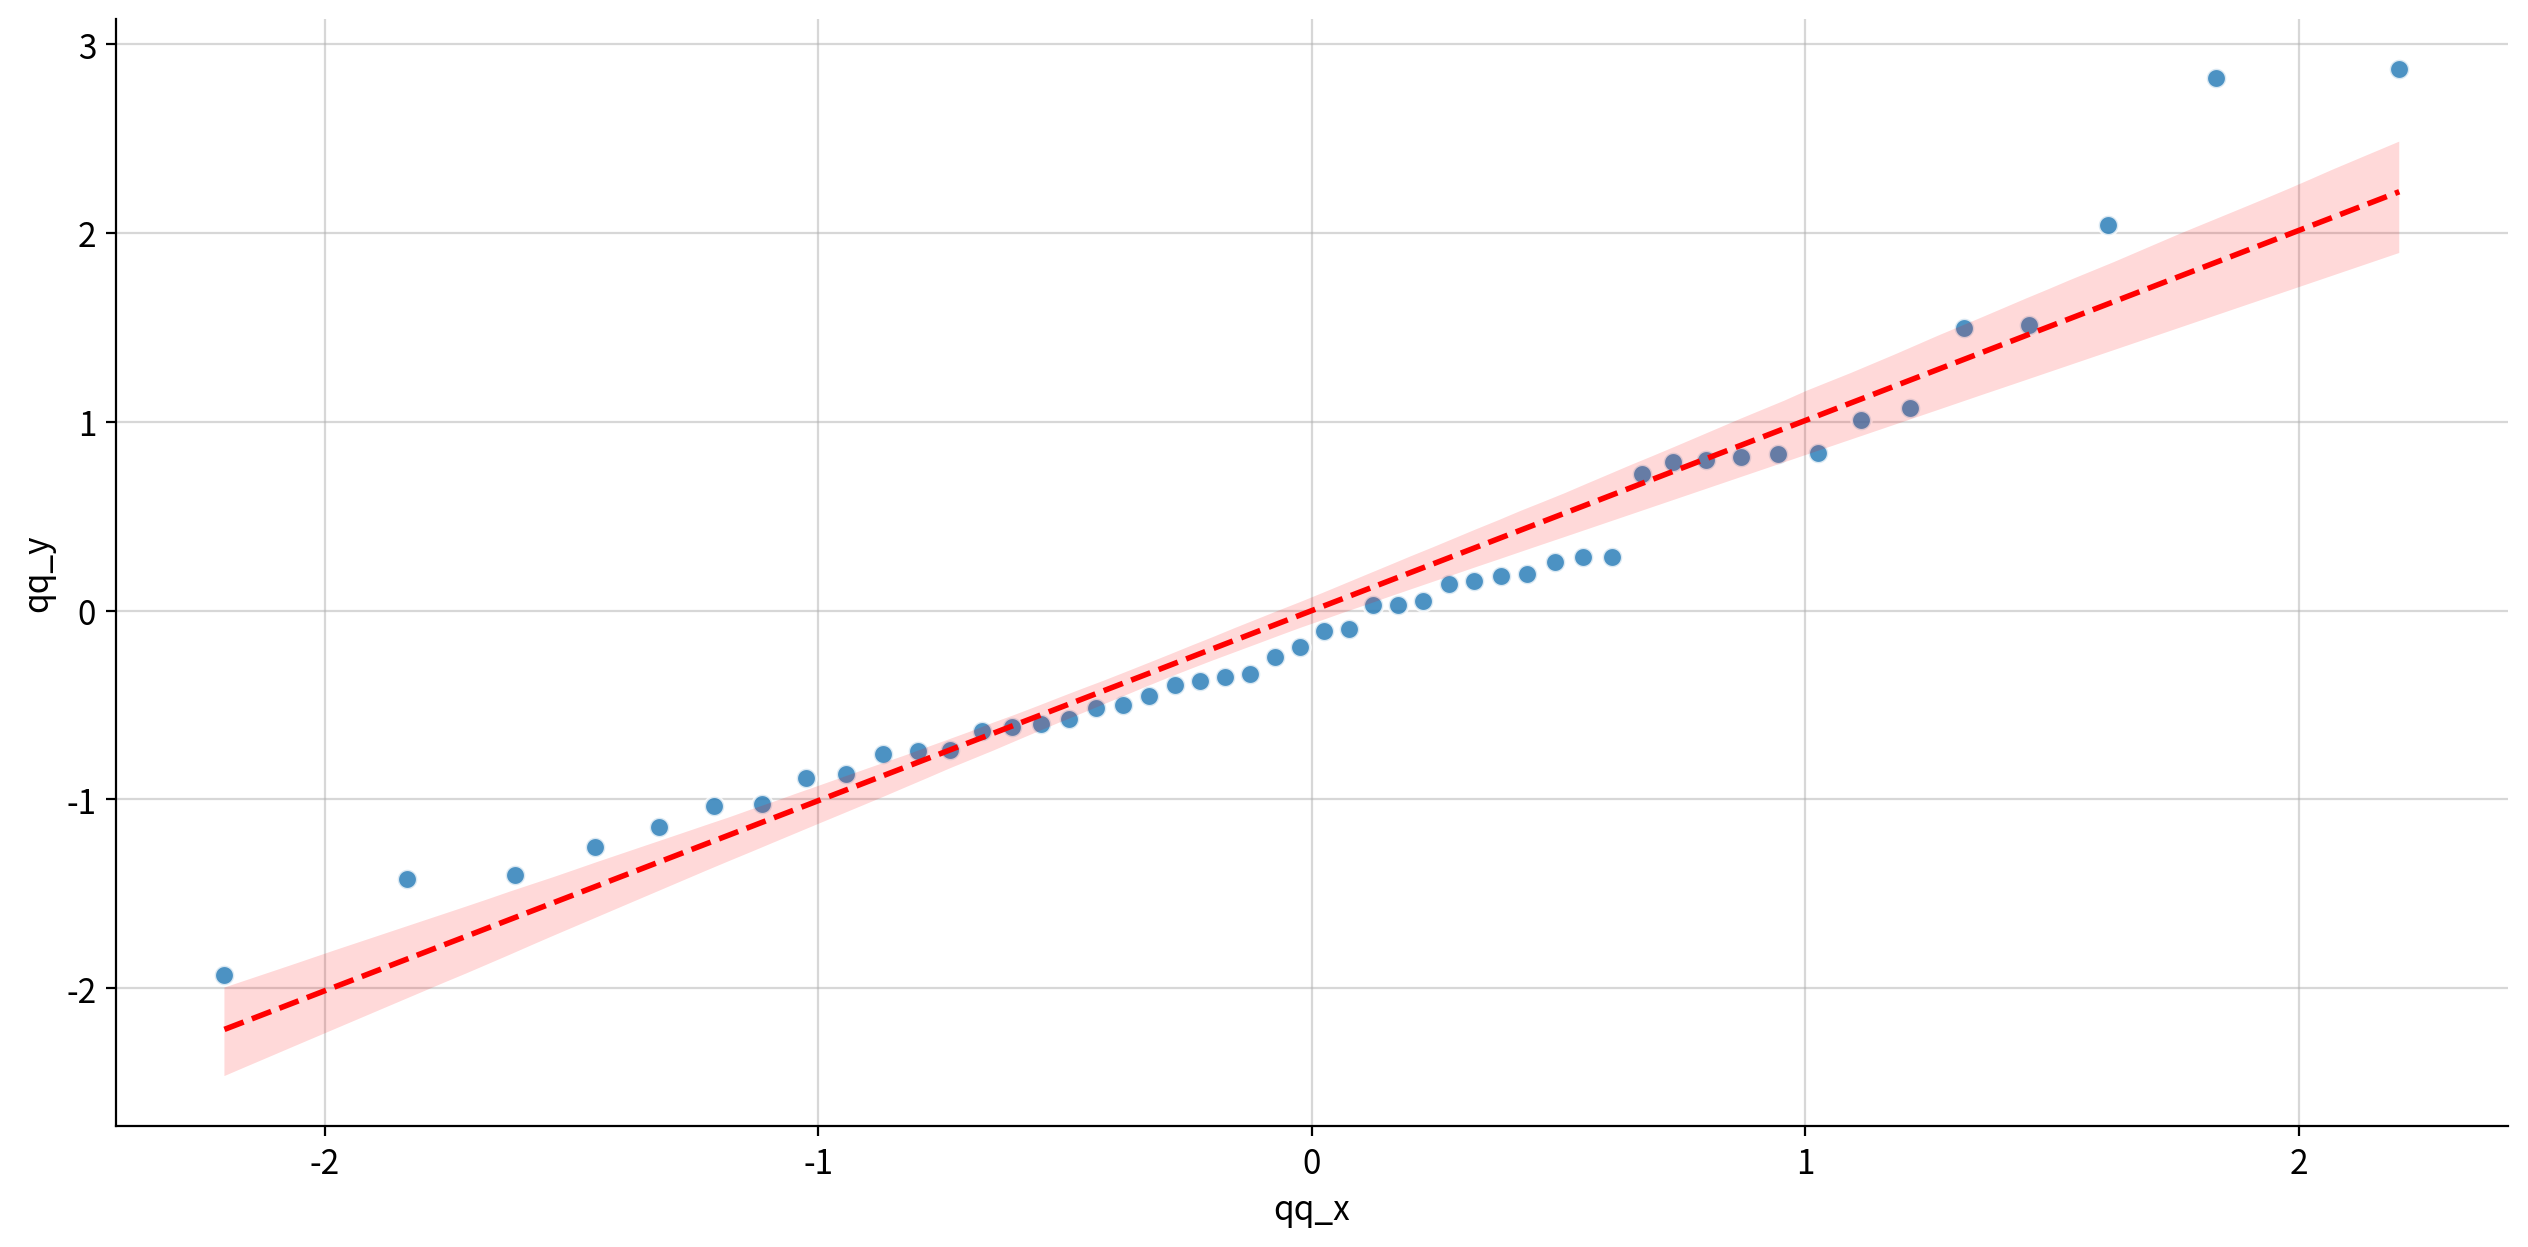

In [28]:
my_plot.lmplot(ols_df, x='qq_x', y='qq_y', linecolor='red', linestyle='--')

- 인사이트
    - 점들이 빨간 기준선(45도)에 대체로 잘 올라타 있다. -> 잔차가 정규분포에 가까움
    - 양쪽 꼬리에서 점이 선을 살짝 벗어난다. 특히 위쪽 끝점이 선위로 뜸 -> 오른쪽으로 약간 두꺼운 꼬리

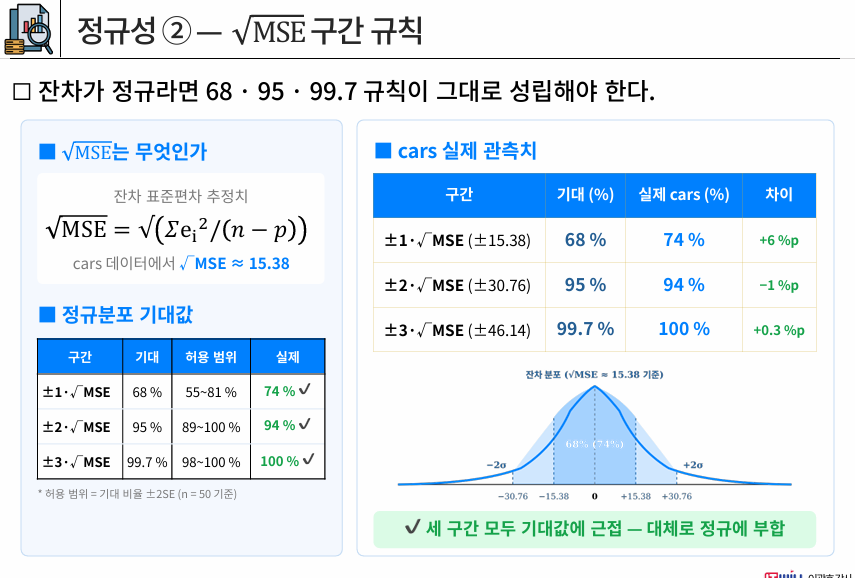

### 4. $\sqrt{MSE}$ 구간 규칙
- 잔차의 분산(MSE, Mean Squared Error of Residuals)를 통해 검정한다.
- 잔차가 정규분포를 따른다면 경험적 규칙(68-95-99.7 규칙)에 따라 대략적으로..
    - $\pm \sqrt{MSE}$ 범위안에 약 68%, $\pm2 \sqrt{MSE}$ 범위 안에 약 95%, $\pm3 \sqrt{MSE}$ 범위 안에 약 99.7%의 잔차가 포함된다.

In [29]:
MSE_sq = np.sqrt(fit.mse_resid) # 잔차 분산의 제곱근
r = fit.resid # 잔차
n = r.count() # 표본수

r1 = r[ (r > -MSE_sq) & (r < MSE_sq)].count() / r.count() * 100
# 잔차가 -√MSE보다 크고 +√MSE보다 작은 데이터의 비율
r2 = r[ (r > -2*MSE_sq) & (r < 2*MSE_sq)].count() / r.count() * 100
r3 = r[ (r > -3*MSE_sq) & (r < 3*MSE_sq)].count() / r.count() * 100

mse_r = [r1, r2, r3]

print(f'√MSE = {MSE_sq:.2f}\n')
print(mse_r)

√MSE = 15.38

[np.float64(74.0), np.float64(94.0), np.float64(100.0)]


| 범위 | 의미 |
|---|---|
| $\lvert e_i \rvert < \sqrt{MSE}$ | 잔차가 루트 MSE 1배 안에 들어온 비율 |
| $\lvert e_i \rvert < 2\sqrt{MSE}$ | 잔차가 루트 MSE 2배 안에 들어온 비율 |
| $\lvert e_i \rvert < 3\sqrt{MSE}$ | 잔차가 루트 MSE 3배 안에 들어온 비율 |

### 5. $\sqrt{MSE}$ 구간 규칙을 통한 정규성 판정 

In [30]:
expected = [68, 95, 99.7]  # 정규분포에서 기대하는 비율
mse_judge = []             # 구간별 규칙 충족 여부

for k, exp, actual in zip([1, 2, 3], expected, mse_r):           # k : 몇배 구간, exp : 기대비율, actual : 실제 잔차 비율
    pe = exp / 100
    se = np.sqrt(pe * (1 - pe) / n)     # 기대 비율의 표준 오차
    lo = max(0, pe - 2*se) * 100        # 허용 범위 하한
    hi = min(1, pe + 2*se) * 100        # 허용 범위 상한
    ok = lo <= actual <= hi             # 실제 비율이 허용 범위 안인가

    mse_judge.append(ok)

    print(
        f"±{k}√MSE 구간: 기대 {exp}%, 허용 {lo:.0f}~{hi:.0f}%, "
        f"실제 {actual:.2f}% → {'충족' if ok else '위배'}"
    )

mse_rule = all(mse_judge)   # 하나라도 위배되면 전체 판정은 False

print(f"\n√MSE 구간 규칙 판정 : {'정규성 부합' if mse_rule else '정규성 위배'}")

±1√MSE 구간: 기대 68%, 허용 55~81%, 실제 74.00% → 충족
±2√MSE 구간: 기대 95%, 허용 89~100%, 실제 94.00% → 충족
±3√MSE 구간: 기대 99.7%, 허용 98~100%, 실제 100.00% → 충족

√MSE 구간 규칙 판정 : 정규성 부합


- 잔차가 정규분포를 따른다면
약 68%는 ±1√MSE,
약 95%는 ±2√MSE,
약 99.7%는 ±3√MSE 안에 들어와야 한다.

실제 잔차 비율이 표본오차를 고려한 허용 범위 안에 들어오는지 보고 잔차의 정규성에 부합하는지 판단한다.


### 6. 잔차도 시각화
- 잔차를 redisplot으로 시각화한 그래프에 $\sqrt{MSE}$ 구간 규칙을 적용한 그래프

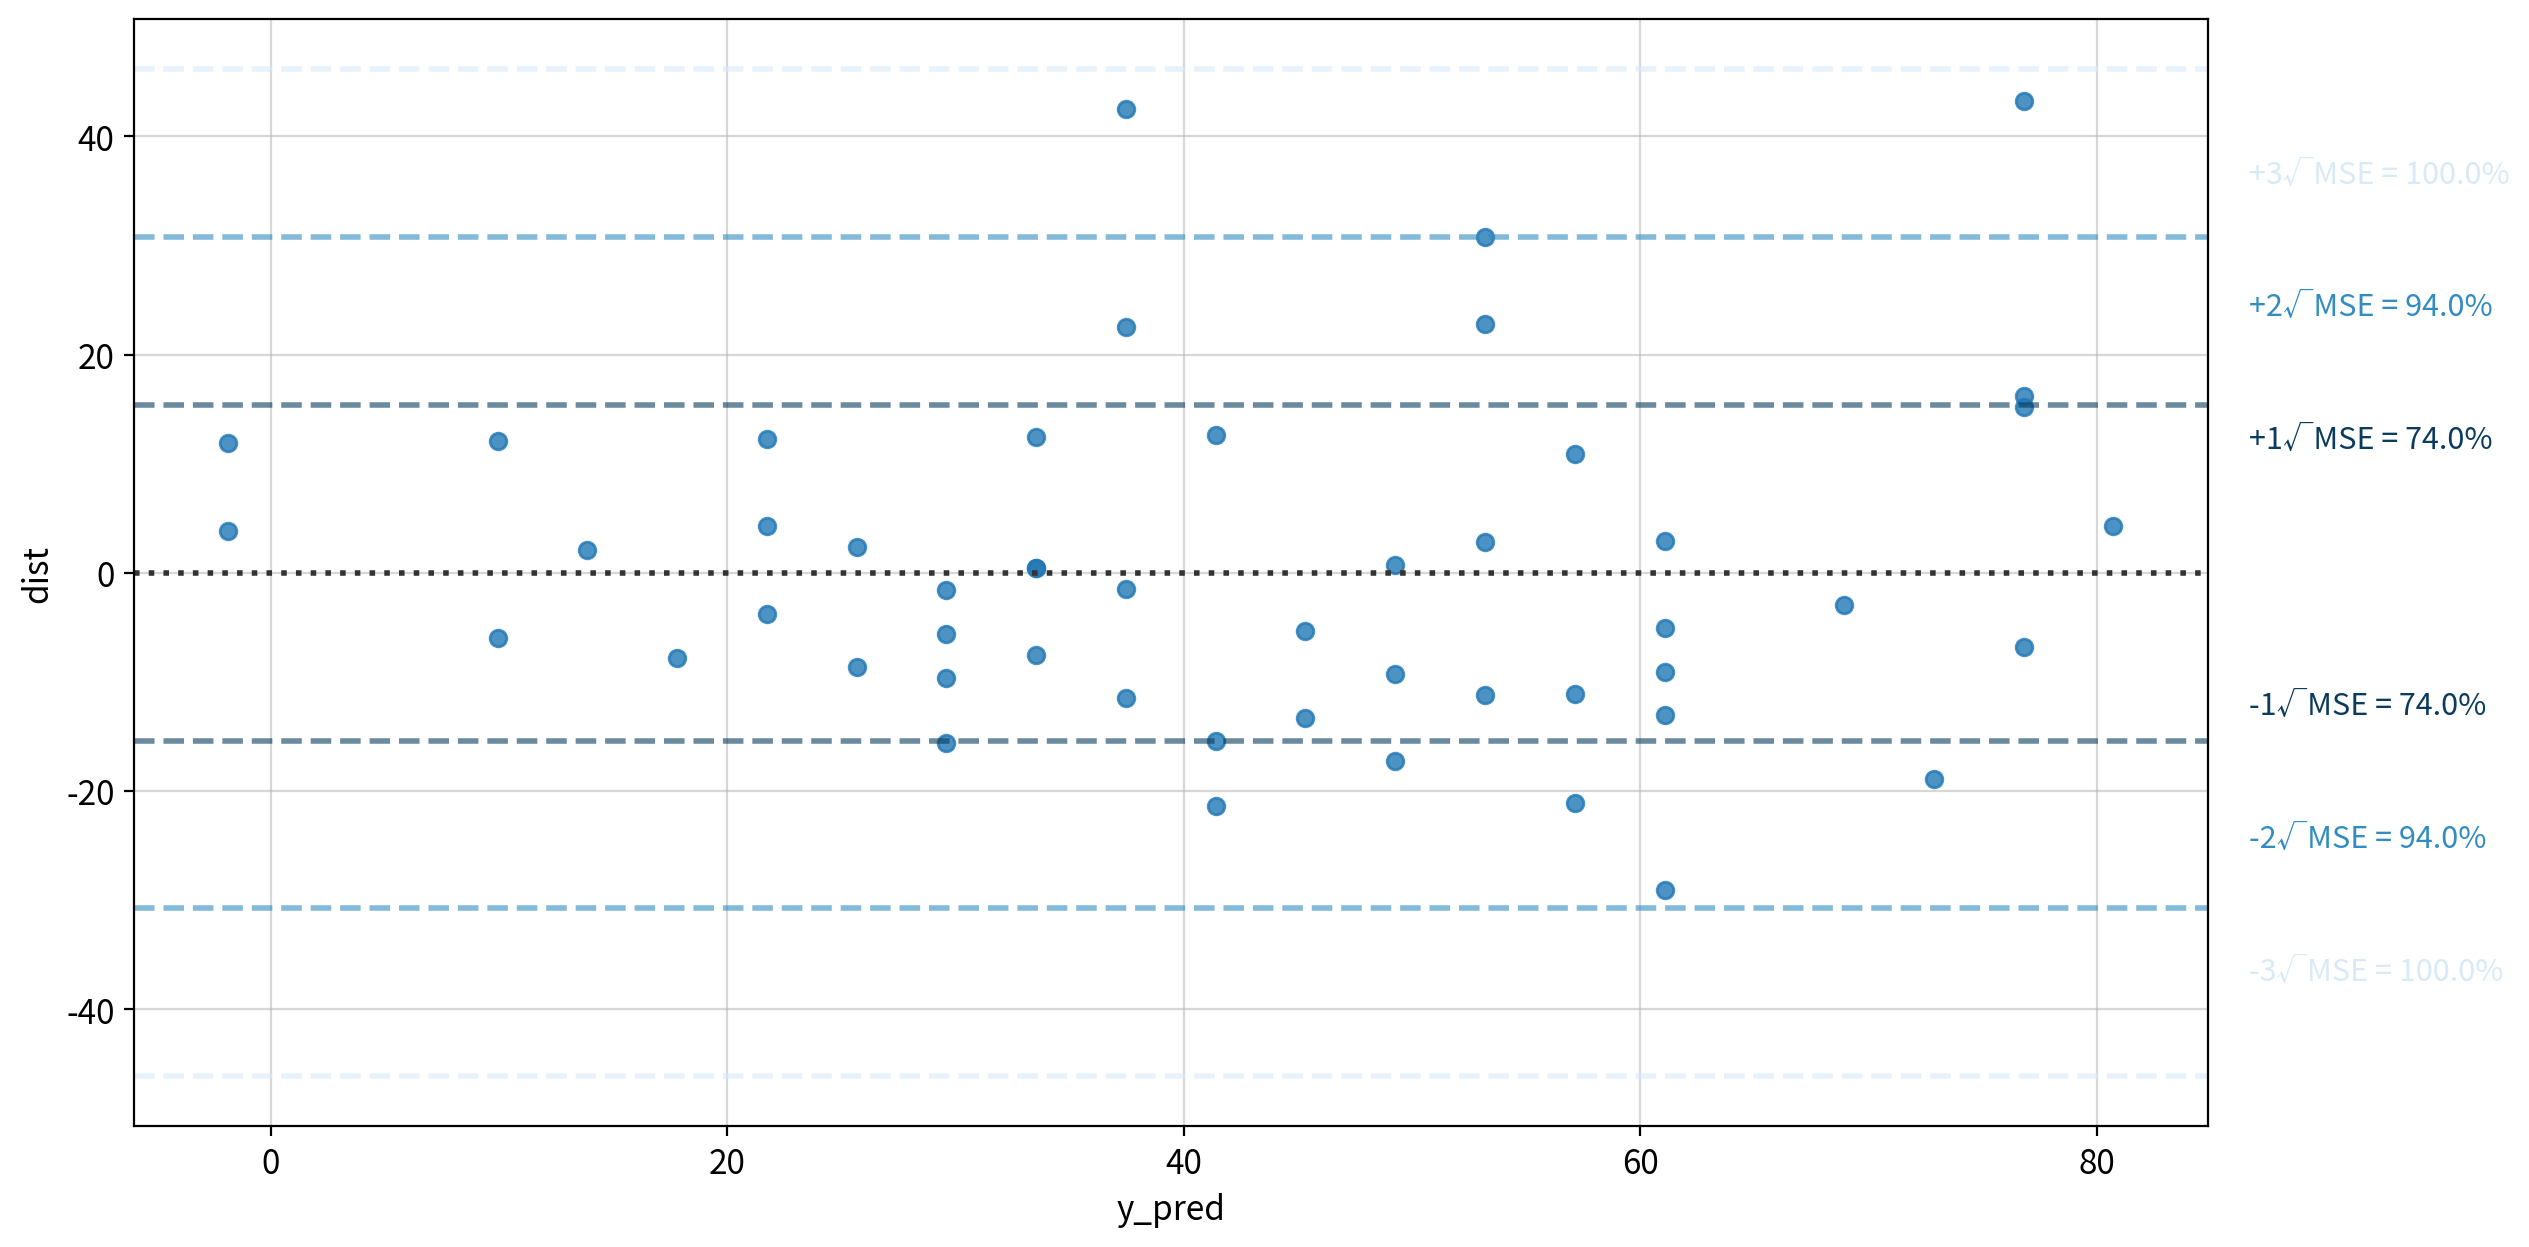

In [32]:
mse_sq = fit.mse_resid                          # 잔차 분산
mse_root = np.sqrt(mse_sq)                      # 잔차 분산의 제곱근
colors = ['#0b3c5d', '#328CC1', '#D9EAF7']      # 구간별 색상
xmax = ols_df['y_pred'].max()
ymin = ols_df['y_pred'].min()

fig, ax = my_plot.init()

# seaborn 기본 잔차도
sb.residplot(data=ols_df, x='y_pred', y='dist', ax=ax)

# MSE 3단계 표기
for i, c in enumerate(colors):
    k = i + 1
    y_pos = k * mse_root
    ax.axhline(y=y_pos, color=c, linestyle="--", alpha=0.6)
    ax.axhline(y=-y_pos, color=c, linestyle="--", alpha=0.6)

    ax.text(x=1.02, y=0.5 + 0.12*k,
            s=f"+{k}√MSE = {mse_r[i]}%",
            transform=ax.transAxes,
            ha="left", va="center", fontsize=11, color=c)

    ax.text(x=1.02, y=0.5 - 0.12*k,
            s=f"-{k}√MSE = {mse_r[i]}%",
            transform=ax.transAxes,
            ha="left", va="center", fontsize=11, color=c)

my_plot.show()


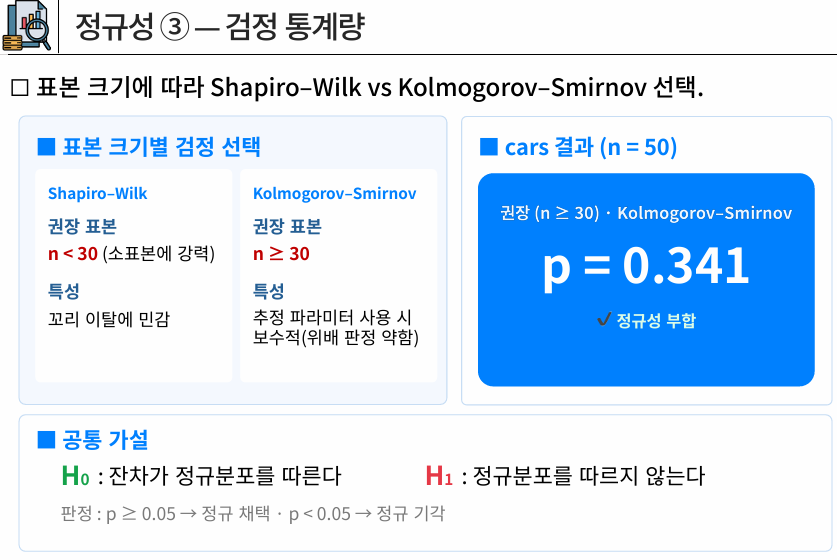

### 7. 검정 통계량을 통한 정규성 검정
- 귀무가설 : 표본의 모집단이 정규분포를 따름
- 대립가설 : 표본의 모집단이 정규분포를 따르기 않음

In [33]:
# 샘플 수에 따라 정규성 검정 선택
if len(origin) < 30:
    method = "Shapiro-Wilk"
    s, p = shapiro(ols_df['resid'])
else:
    method = "Kolmogorov-Smirnov"

    mu = ols_df['resid'].mean()
    sigma = ols_df['resid'].std(ddof=1)

    # 잔차를 표준화한 뒤 표준정규분포(N(0,1))와 비교한다.
    z = (ols_df['resid'] - mu) / sigma
    s, p = kstest(z, 'norm')

print(f"{method} 검정 결과: statistic={s:.4f}, p-value={p:.4f}")

Kolmogorov-Smirnov 검정 결과: statistic=0.1296, p-value=0.3410


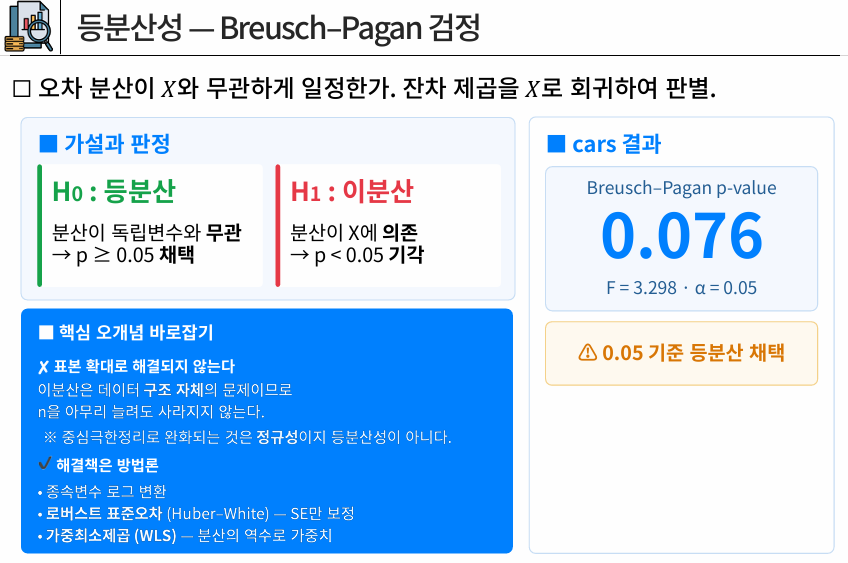

## #05. 잔차의 등분산성
### 1. 브로이슈 패건 검정
- 귀무가설 : 등분산성 가정이 만족된다.
- 대립가설 : 등분산성 가정이 만족되지 않는다.

In [34]:
# Breusch-Pagan Test
names = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_test = het_breuschpagan(fit.resid, fit.model.exog)
bp = DataFrame(bp_test, index=names, columns=['value'])

display(bp)

,value
LM Statistic,3.215
LM p-value,0.073
F Statistic,3.298
F p-value,0.076


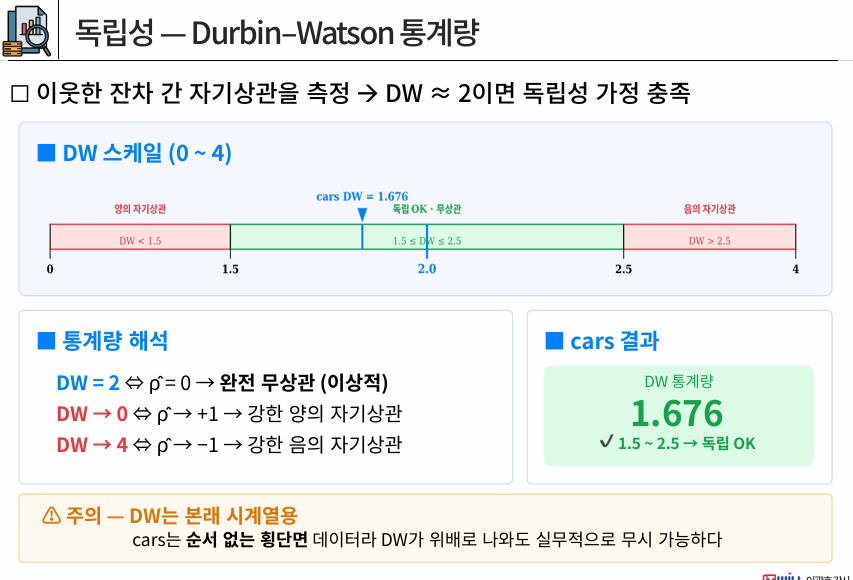

## #06. 잔차의 독립성
### 1. Dubin - wason

In [35]:
dw = durbin_watson(ols_df['resid'])

if 1.5 <= dw <= 2.5:
    interpretation = "잔차는 독립성을 만족함"
elif dw < 1.5:
    interpretation = "잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
else:
    interpretation = "잔차에 음(-)의 자기상관이 존재할 가능성 있음 (독립성 위반)"

print(f"Durbin-Watson = {dw:.3f} ::: {interpretation}")

Durbin-Watson = 1.676 ::: 잔차는 독립성을 만족함


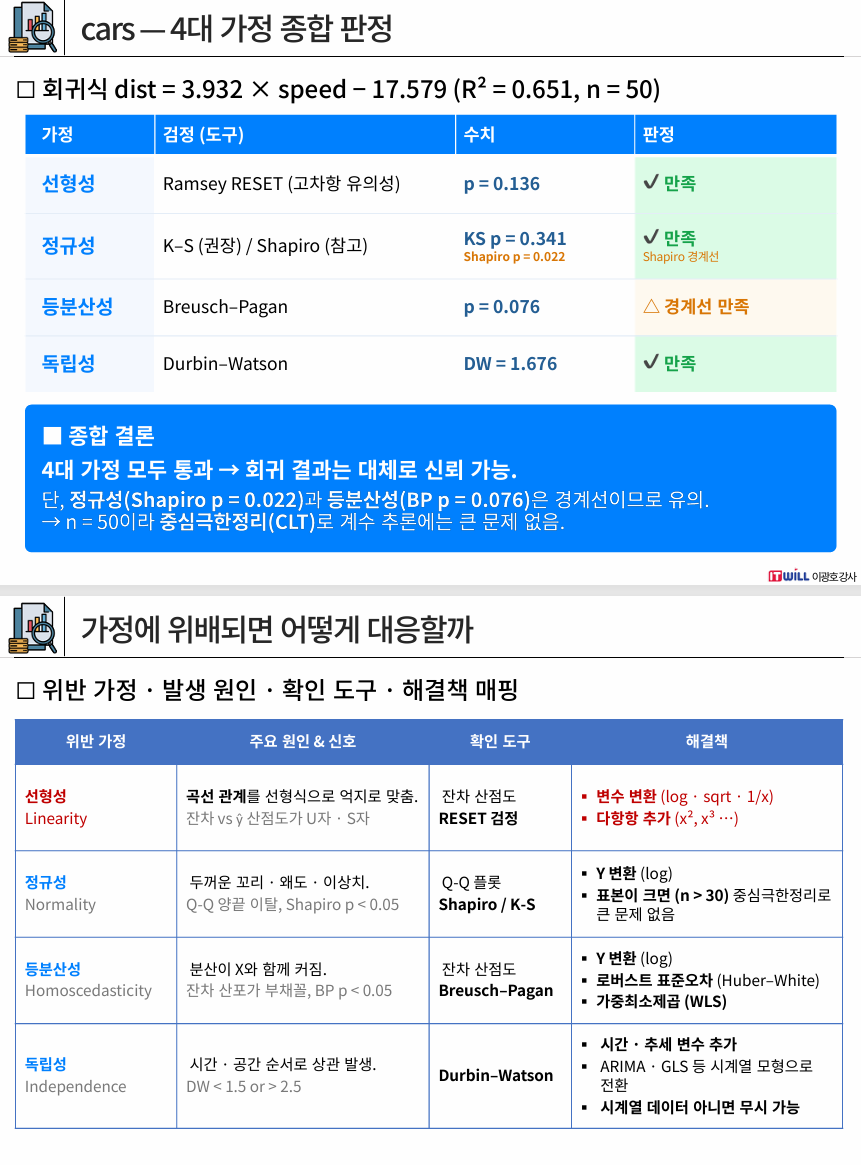